In [5]:
import pandas as pd
from sklearn.metrics import precision_score, accuracy_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# we MUST scale in kNN!
from sklearn.neighbors import KNeighborsClassifier

In [7]:
heart_df = pd.read_csv("1-heart.csv")
x = heart_df.drop("target", axis=1)
y = heart_df["target"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size = 0.2, random_state=42
)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [8]:
# form knn model
knn_classifier = KNeighborsClassifier(n_neighbors=3)
knn_classifier.fit(x_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [13]:
y_pred = knn_classifier.predict(x_test_scaled)
print("accuracy: ", accuracy_score(y_test, y_pred))
print("precision: ", precision_score(y_test, y_pred))
print("recall score: ", recall_score(y_test, y_pred))

accuracy:  0.8524590163934426
precision:  0.9259259259259259
recall score:  0.78125


In [15]:
# repeat predicitions for n = 5
# form knn model
knn_classifier = KNeighborsClassifier(n_neighbors=5)
knn_classifier.fit(x_train_scaled, y_train)
y_pred = knn_classifier.predict(x_test_scaled)
print("accuracy: ", accuracy_score(y_test, y_pred))
print("precision: ", precision_score(y_test, y_pred))
print("recall score: ", recall_score(y_test, y_pred))

accuracy:  0.9016393442622951
precision:  0.9333333333333333
recall score:  0.875


In [17]:
# increasing the number of neighbours gives a better performance up to n = 9
# better performance than logistic regression up until before that
# we use cross validation to find the best value for the hyperscaler k
# limitations of knn include:
# slow at predictions (not suitable for huge datasets)
# sensitive to others
# sensitive to feature scaling -> the bigger the magnitudes -> favours kNN
# curse of dimensionality (high dimensional data) -> data sparsity -> distance stops making sense -> kNN fails

In [18]:
# validation data
# a validation dataset is a sample of data hed back from training your model 
# that is used to give an estimate of model skill while tuning model's hyperparameters
# e.g., finding optimal k
# types of cross validation e.g., K-Fold CV
# test data = 200 and training data = 800 vals
# e.g., k = 5 and CV = 5
# split training data into k folds and iterate through each one which gives an accuracy
# train each fold on some validation data and then you should get k accuracy vals
# final val will the average of all the iterations
# reliable and reduces bias
# CV used for hyperparameter tuning
# GridSearchCV used for the above and employs a scoring func e.g., accuracy/precision
# depends on algo used
# GridSearchCV also passses a parameter grid

In [25]:
# Cross validation used for hyperparameter tuning using GridSearchCV
from sklearn.model_selection import GridSearchCV
classifier = KNeighborsClassifier()
param_grid = {"n_neighbors": [3,5,7,9]}

classifierCV = GridSearchCV(
    classifier,
    param_grid,
    cv=5,
    scoring="recall" # for medical applications
)

classifierCV.fit(x_train_scaled, y_train)
y_pred = knn_classifier.predict(x_test_scaled)

print("accuracy: ", accuracy_score(y_test, y_pred))
print("precision: ", precision_score(y_test, y_pred))
print("recall score: ", recall_score(y_test, y_pred))

# results
res = pd.DataFrame(classifierCV.cv_results_)
print(res[["param_n_neighbors", "mean_test_score"]])
print(classifierCV.best_params_)

accuracy:  0.9016393442622951
precision:  0.9333333333333333
recall score:  0.875
   param_n_neighbors  mean_test_score
0                  3         0.864387
1                  5         0.857550
2                  7         0.871795
3                  9         0.856980
{'n_neighbors': 7}


In [26]:
# therefore according to above the best value of k is 5
# changed from 5 to 7 once we used scoring="recall"
# pipeline: allows us to sequentially apply a list of transformers to precprocess data
# and, if desired, conclude the sequence with a final predictor for predictive modelling
# we went it so only training data is scaled on every iteration and validation data stays the same
# to prevent data leakages ^^
# want data to be scale -> trained//kNN -> validate

In [36]:
# process performed with pipeline:


from sklearn.pipeline import Pipeline

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size = 0.2, random_state=42
)
pipeline = Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier())])

param_grid = {"knn__n_neighbors": [3,5,7,9]}

classifierCV = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="recall" # for medical applications
)

classifierCV.fit(x_train, y_train)
y_pred = classifierCV.predict(x_test) # don't pass scaled data

print("accuracy: ", accuracy_score(y_test, y_pred))
print("precision: ", precision_score(y_test, y_pred))
print("recall score: ", recall_score(y_test, y_pred))

print(classifierCV.best_params_)

accuracy:  0.9180327868852459
precision:  0.9354838709677419
recall score:  0.90625
{'knn__n_neighbors': 7}


In [50]:
# KNN implementation from scratch
# step 1: initialise k with an odd value
# step 2: new data pt -> training datapts distance (usually euclidian)
# step 3: minimum distance for k data points
# step 4: knn majority 0 or majority 1 prediction set
import numpy as np
import seaborn as sns
import pandas as pd

# for binary classsification 
class KNNClassifier():
    def __init__(self, k=3):
        self.k = k

    def euclidean_dist(self, x1, x2):
        return np.sqrt(np.sum((x1 - x2) ** 2))

    def fit(self, x, y):
        #lazy learner
        self.x_train = np.array(x)
        self.y_train = np.array(y) 

    def predict_one(self, X):
        distances = [self.euclidean_dist(X, x_train) for x_train in self.x_train]
        knn_indices = np.argsort(distances)[:self.k]
        knn_classes = [self.y_train[i] for i in knn_indices]
        majority_class = np.argmax(np.bincount(knn_classes)) 
        return majority_class

    def predict(self, x):
        y_pred = [self.predict_one(X) for X in x]
        return np.array(y_pred)


x_train=[[1],[2],[3],[4],[5]]
y_train=[2,4,6,8,10]
x_test=[[1.5],[3.5],[6]]

model = KNNClassifier(k=3)
model.fit(x_train, y_train)
predictions = model.predict(x_test)
print(f"Predictions for {x_test}: {predictions}")

Predictions for [[1.5], [3.5], [6]]: [2 4 6]


In [51]:
x1 = np.array([1,2])
x2 = np.array([3,4])

np.sqrt(np.sum((x1 - x2) ** 2))

distances = [5, 2, 4, 1, 0] #[0,1,2,3,4,5]
np.argsort(distances) # gives sorted index values and not the actual values themselves -> first 3 are the k nearest neighbours

knn_classes = [0,0,1,1,0,0,3,3,5]
np.argmax(np.bincount(knn_classes)) # bincount gives the freq of all the classes for all numbers >= 0

np.int64(0)

<Axes: xlabel='x1', ylabel='x2'>

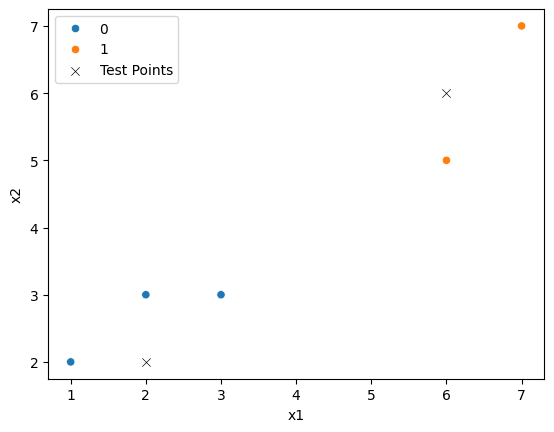

In [46]:
# data
x_train = np.array([[1,2],[2,3],[3,3],[6,5],[7,7]])
x_test = np.array([[2,2],[6,6]])
y_train = np.array([0,0,0,1,1])
# visualise
x_train_df = pd.DataFrame(x_train, columns=["x1","x2"])
x_train_df["label"] = y_train

sns.scatterplot(
    data=x_train_df,
    x="x1",
    y="x2",
    hue="label"
)

x_train_df = pd.DataFrame(x_test, columns=["x1","x2"])
sns.scatterplot(
    data = x_train_df,
    x="x1",
    y="x2",
    color="black",
    marker="x",
    label="Test Points"
)

In [47]:
x_train_df

,x1,x2
0,2,2
1,6,6
